# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [3]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

df_eng = pd.read_csv('../data/engagement_based_perspective_clusters.csv', index_col='Loyalty#')

df_beh = pd.read_csv('../data/behvioral_segment_data.csv', index_col='Loyalty#')

df_val = pd.read_csv('../data/value_based_perspective_clusters.csv', index_col='Loyalty#')

def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss

def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()

# <span style="color:#0097b2">1. Data Preparation & Label Extraction</span>
[Back to TOC](#toc)

In [4]:
df_merged = df_val.copy()

# Add missing columns from Behavior DF
cols_to_add_beh = df_beh.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_beh[cols_to_add_beh])

# Add missing columns from Engagement DF
cols_to_add_eng = df_eng.columns.difference(df_merged.columns)
df_merged = df_merged.join(df_eng[cols_to_add_eng])

In [5]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,seg_Jan_Feb_travelers,seg_No_Activity,seg_Active_Travelers,seg_Active_Travelers.1,seg_Dormant_Travelers,seg_Dormant_Travelers.1,seg_Low_Engagement,seg_Low_Engagement.1,seg_Non_Travelers,seg_Non_Travelers.1
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,0,0,0,0,1,1


In [ ]:
def decode_ohe_segments(df, prefix):
    seg_cols = [c for c in df.columns if c.startswith(prefix)]
    return df[seg_cols].idxmax(axis=1)

In [7]:
df_merged['Value_Label'] = decode_ohe_segments(
    df_val, prefix='seg_'
)

df_merged['Behavior_Label'] = decode_ohe_segments(
    df_beh, prefix='seg_'
)

df_merged['Engagement_Label'] = decode_ohe_segments(
    df_eng, prefix='seg_'
)

df_merged['Location_Label'] = decode_ohe_segments(
    df_val, prefix='Location_'
)

In [8]:
features_to_exclude = [c for c in df_merged.columns if c.startswith('seg_')]

# but this logic works if your dataframe only contains relevant metric columns.
metric_features = (
    df_merged
    .drop(columns=features_to_exclude)
    .select_dtypes(include='number')
    .columns
    .tolist()
)

In [9]:
df_centroids = df_merged.groupby(['Value_Label', 'Behavior_Label', 'Engagement_Label', 'Location_Label'])[metric_features].mean()
df_centroids

Income  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                 
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0     12681.642857   
                                                                 Location__1     22457.424779   
                                                                 Location__2     21900.227273   
                                                                 Location__3     19953.531250   
                                                                 Location__4     21354.098901   
...                                                                                       ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4     75929.976804   
                                                                 Location__5     75701.455172   
                                                                 Location__6     74739.142857   
                                                                 Location__7     73509.181818   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1     79271.000000   

                                                                                 Customer Lifetime Value  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                            
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0                 9148.976071   
                                                                 Location__1                 8301.304336   
                                                                 Location__2                 7355.275273   
                                                                 Location__3                 9218.923125   
                                                                 Location__4                 7853.721648   
...                                                                                                  ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4                 7983.713686   
                                                                 Location__5                 8552.552690   
                                                                 Location__6                 7830.001429   
                                                                 Location__7                 4615.874545   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1                 2414.640000   

                                                                                 EnrollmentType  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                   
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0           0.178571   
                                                                 Location__1           0.150442   
                                                                 Location__2           0.136364   
                                                                 Location__3           0.125000   
                                                                 Location__4           0.109890   
...                                                                                         ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4           0.038660   
                                                                 Location__5           0.062069   
                                                                 Location__6           0.000000   
                                                                 Location__7           0.000000   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1           0.000000   

                                                                                 rejoined_program  \
Value_Label          Behavior_L

# <span style="color:#0097b2">2. Micro-Segmentation Strategy</span>
[Back to TOC](#toc)

In [10]:
# Fit hierarchical clustering with distance tracking
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


In [11]:
print(f"\nCentroids shape: {df_centroids.shape}")


Centroids shape: (302, 63)


# <span style="color:#0097b2">3. Hierarchical Clustering (The Merge)</span>
[Back to TOC](#toc)

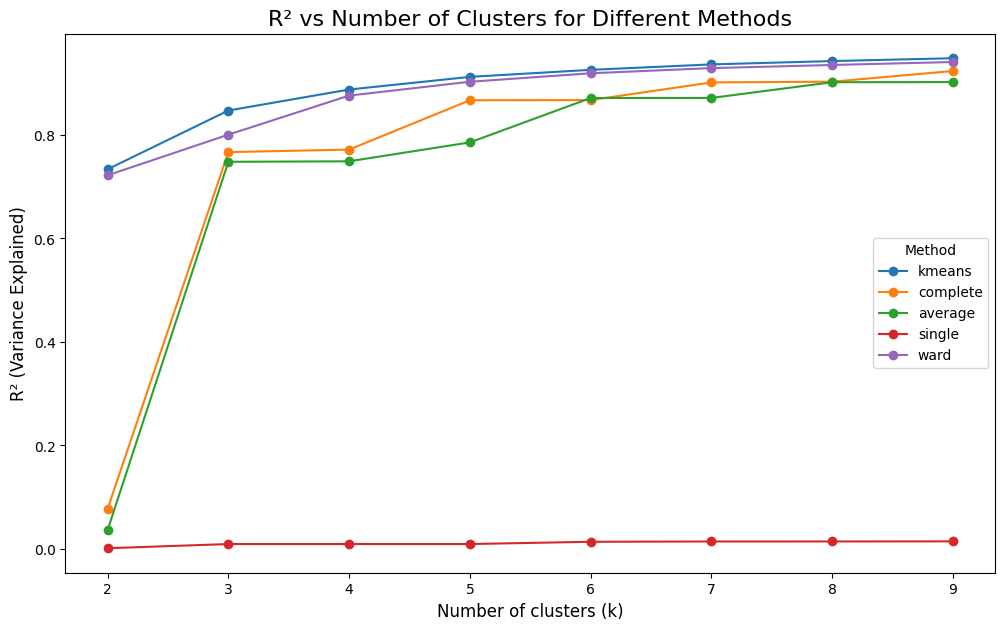

In [12]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
import pandas as pd

r2_scores_merged = {}

# KMeans over a range of clusters
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_merged[metric_features])
    r2_scores_merged[f'kmeans_{k}'] = get_rsq(
        df_merged.assign(cluster=labels), metric_features, 'cluster'
    )

# Hierarchical clustering with different linkages
for linkage in ['complete', 'average', 'single', 'ward']:
    for k in range(2, 10):
        hc = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hc.fit_predict(df_merged[metric_features])
        r2_scores_merged[f'{linkage}_{k}'] = get_rsq(
            df_merged.assign(cluster=labels), metric_features, 'cluster'
        )

# Convert to DataFrame for plotting
r2_df = pd.DataFrame(r2_scores_merged, index=[0]).T.reset_index()
r2_df[['method', 'k']] = r2_df['index'].str.rsplit('_', n=1, expand=True)
r2_df['k'] = r2_df['k'].astype(int)

# Plotting R²
plt.figure(figsize=(12,7))
for method in r2_df['method'].unique():
    subset = r2_df[r2_df['method'] == method]
    plt.plot(subset['k'], subset[0], marker='o', label=method)

plt.title("R² vs Number of Clusters for Different Methods", fontsize=16)
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("R² (Variance Explained)", fontsize=12)
plt.legend(title="Method")
plt.show()


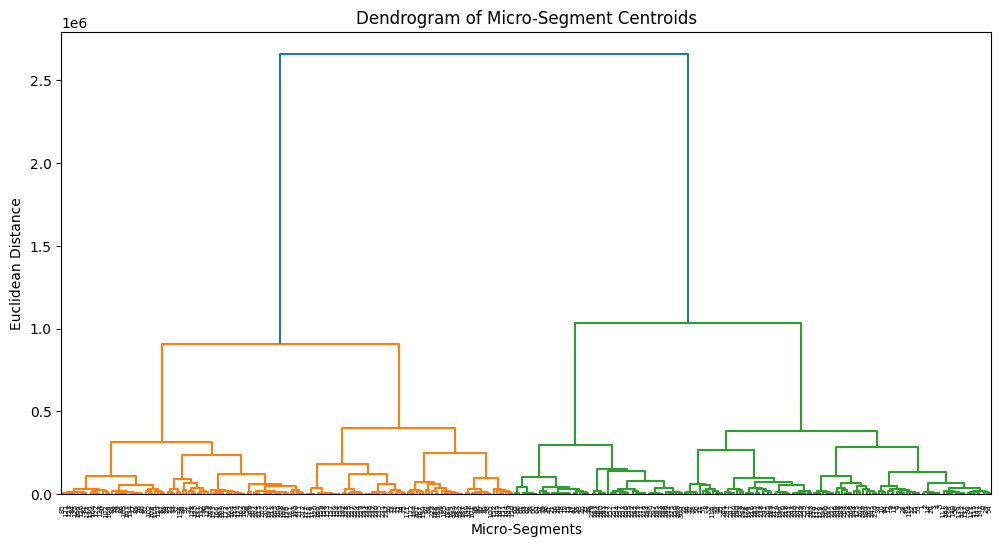

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.title('Dendrogram of Micro-Segment Centroids')

Z = linkage(df_centroids.values, method='ward')
dendro = dendrogram(Z)

plt.xlabel('Micro-Segments')
plt.ylabel('Euclidean Distance')
plt.show()


In [29]:
#HC WARD METHOD

n_final_clusters = 8

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels

# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

Income  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                 
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0     12681.642857   
                                                                 Location__1     22457.424779   
                                                                 Location__2     21900.227273   
                                                                 Location__3     19953.531250   
                                                                 Location__4     21354.098901   
...                                                                                       ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4     75929.976804   
                                                                 Location__5     75701.455172   
                                                                 Location__6     74739.142857   
                                                                 Location__7     73509.181818   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1     79271.000000   

                                                                                 Customer Lifetime Value  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                            
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0                 9148.976071   
                                                                 Location__1                 8301.304336   
                                                                 Location__2                 7355.275273   
                                                                 Location__3                 9218.923125   
                                                                 Location__4                 7853.721648   
...                                                                                                  ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4                 7983.713686   
                                                                 Location__5                 8552.552690   
                                                                 Location__6                 7830.001429   
                                                                 Location__7                 4615.874545   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1                 2414.640000   

                                                                                 EnrollmentType  \
Value_Label          Behavior_Label        Engagement_Label      Location_Label                   
seg_Core_Loyalists   seg_Active_Redeemers  seg_Active_Travelers  Location__0           0.178571   
                                                                 Location__1           0.150442   
                                                                 Location__2           0.136364   
                                                                 Location__3           0.125000   
                                                                 Location__4           0.109890   
...                                                                                         ...   
seg_Low_Value_Active seg_Holiday_travelers seg_Low_Engagement    Location__4           0.038660   
                                                                 Location__5           0.062069   
                                                                 Location__6           0.000000   
                                                                 Location__7           0.000000   
                     seg_Jan_Feb_travelers seg_Dormant_Travelers Location__1           0.000000   

                                                                                 rejoined_program  \
Value_Label          Behavior_L

In [ ]:
#KMEANS METHOD

kmeans_demo = KMeans(
    n_clusters=7,
    init='k-means++',
    n_init=20,
    random_state=42
)

demo_labels = kmeans_demo.fit_predict(df_centroids)
demo_labels

# Add to centroids dataframe
df_centroids['merged_labels'] = demo_labels
df_centroids

In [ ]:
# Re-run KMeans on the full dataset directly
#kmeans_optimal = KMeans(n_clusters=7, random_state=42)
#df_merged['merged_labels'] = kmeans_optimal.fit_predict(df_merged[metric_features])

#print(get_rsq(df_merged, metric_features, 'merged_labels'))

In [30]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  

{('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__0'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__1'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__2'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__3'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__4'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__5'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__6'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Active_Travelers',
  'Location__7'): 0,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Dormant_Travelers',
  'Location__0'): 2,
 ('seg_Core_Loyalists',
  'seg_Active_Redeemers',
  'seg_Dormant_Travelers',
  'Location__1'): 0,
 ('seg_Core_Loyalists',
  's

In [31]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__3,Location__4,Location__5,Location__6,Location__7,Value_Label,Behavior_Label,Engagement_Label,Location_Label,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,1,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__5,4
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4


In [32]:
# Drop all columns starting with 'seg_' and the original label columns
cols_to_drop = [col for col in df_merged.columns if col.startswith('seg_')]

df_merged = df_merged.drop(columns=cols_to_drop)

In [33]:
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__3,Location__4,Location__5,Location__6,Location__7,Value_Label,Behavior_Label,Engagement_Label,Location_Label,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,1,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__5,4
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4


In [34]:
df_merged['merged_labels'] = df_merged.apply(
    lambda row: cluster_mapper[(row['Value_Label'], row['Behavior_Label'], row['Engagement_Label'], row['Location_Label'])],
    axis=1
)
df_merged

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__3,Location__4,Location__5,Location__6,Location__7,Value_Label,Behavior_Label,Engagement_Label,Location_Label,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,1,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__5,4
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,1,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__4,4
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__1,4
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,seg_Elite_High_Value_Loyalists,seg_August_to_December_travelers,seg_Non_Travelers,Location__3,4


In [35]:
print(df_merged['merged_labels'].value_counts().sort_index())

merged_labels
0     953
1    1860
2     866
3    3110
4    1566
5     932
6     857
7    6571
Name: count, dtype: int64


In [36]:
# Quick distinctiveness check (R²)
r2_merged = get_rsq(df_merged, metric_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.7813


# <span style="color:#0097b2">4. Profiling & Feature Importance</span>
[Back to TOC](#toc)

In [20]:
# 1. Calculate R2 for ALL variables (Active + Passive)
# (excluding ID columns or text columns)
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
# Remove the cluster labels themselves
numeric_cols = [c for c in numeric_cols if c not in ['Final_Solution_Label', 'Location_cluster', 'EnrollmentType']]

def get_r2_scores(df, cluster_col, features):
    sst_total = df[features].var() * (len(df) - 1)
    r2_scores = {}
    for feature in features:
        sst = sst_total[feature]
        if sst == 0: continue # Skip constant columns
        ssw = 0
        for cluster in df[cluster_col].unique():
            cluster_data = df[df[cluster_col] == cluster][feature]
            ssw += cluster_data.var() * (len(cluster_data) - 1)
        r2_scores[feature] = (sst - ssw) / sst
    return pd.Series(r2_scores).sort_values(ascending=False)

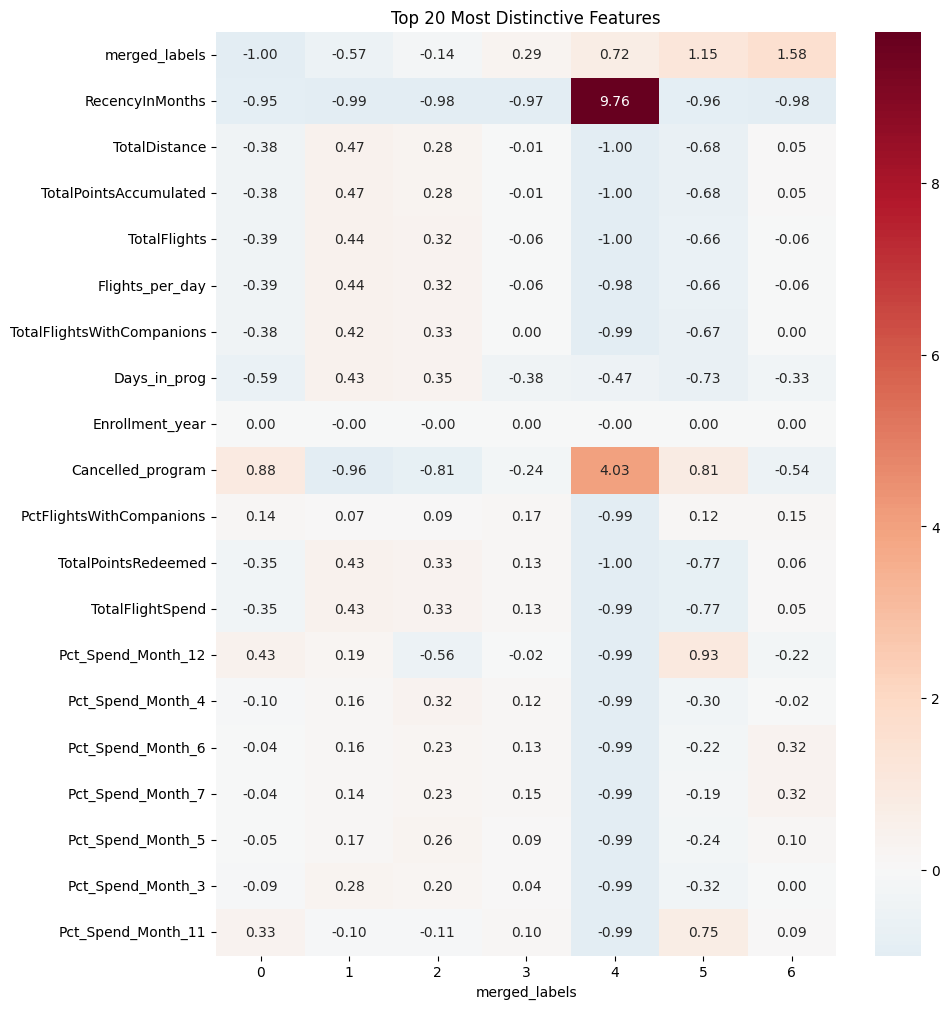

In [21]:
# 2. Get Top 20 Differentiating Features
top_features = get_r2_scores(df_merged, 'merged_labels', numeric_cols).head(20).index.tolist()

# 3. Plot Heatmap ONLY for these Top 20
cluster_means = df_merged.groupby('merged_labels')[top_features].mean()
global_means = df_merged[top_features].mean()
relative_imp = (cluster_means / global_means) - 1

plt.figure(figsize=(10, 12))
sns.heatmap(data=relative_imp.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Top 20 Most Distinctive Features')
plt.show()

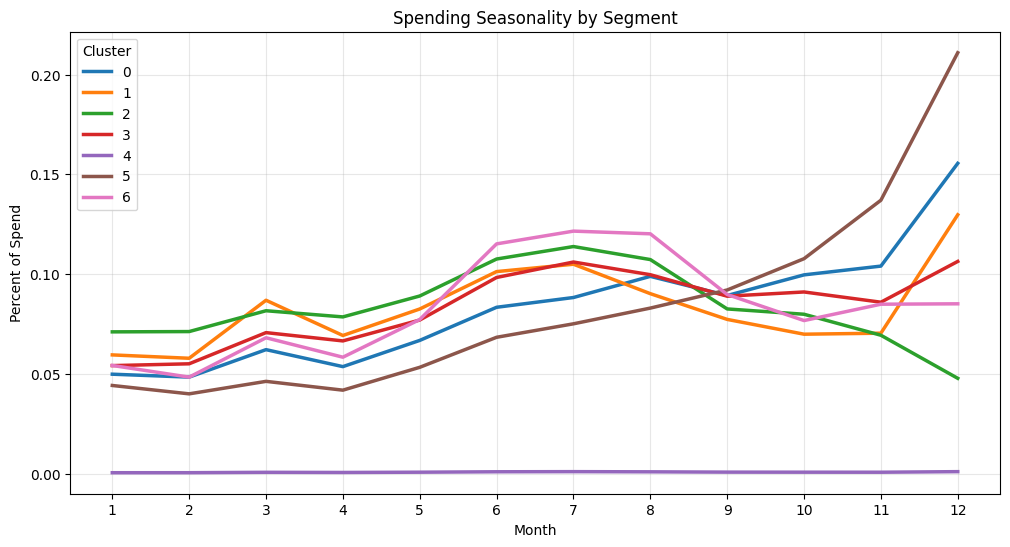

In [22]:
# Create a temporary dataframe for plotting
seasonality_cols = [f'Pct_Spend_Month_{i}' for i in range(1, 13)]

# Group by Cluster and get the mean of monthly spend
monthly_profile = df_merged.groupby('merged_labels')[seasonality_cols].mean()

# Rename columns to just numbers 1-12 for the X-axis
monthly_profile.columns = range(1, 13)

# Plot
plt.figure(figsize=(12, 6))
# Transpose so Months are on X-axis
sns.lineplot(data=monthly_profile.T, dashes=False, palette='tab10', linewidth=2.5)

plt.title('Spending Seasonality by Segment')
plt.xlabel('Month')
plt.ylabel('Percent of Spend')
plt.xticks(range(1, 13))
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()